# INTERPRETACIÓN DE RESULTADOS – ESTADÍSTICA
## Análisis de Anchuras de Cráneos Egipcios
### Predinástico Temprano vs. Predinástico Tardío

Obtendremos las Medidas de ambas muestras:

**a)** Obtener con Python las diferentes medidas de centralización y dispersión, asimetría y curtosis estudiadas. Así mismo, obtener el diagrama de caja y bigotes. Se debe hacer por separado para la submuestra de los cráneos del **predinástico temprano** y para la submuestra de los del **predinástico tardío**. Comentar los resultados obtenidos.

In [1]:
# ─── Importación de librerías ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─── Carga del dataset ───────────────────────────────────────────────────────
df = pd.read_excel('datosejercicioevaluacionanchuras.xlsx')
print("Vista previa del dataset:")
print(df.head(10))
print(f"\nShape total: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"Épocas: {df['Época histórica'].unique()}")

Vista previa del dataset:
   Época histórica  Anchura del cráneo
0                1                 133
1                1                 131
2                1                 131
3                1                 132
4                1                 134
5                1                 131
6                1                 132
7                1                 132
8                1                 131
9                1                 131

Shape total: (60, 2)
Columnas: ['Época histórica', 'Anchura del cráneo']
Épocas: [1 2]


In [2]:
# ─── Separación de submuestras ───────────────────────────────────────────────
muestra_temprano = df[df['Época histórica'] == 1]['Anchura del cráneo'].reset_index(drop=True)
muestra_tardio   = df[df['Época histórica'] == 2]['Anchura del cráneo'].reset_index(drop=True)

print(f"Submuestra Periodo Temprano (n={len(muestra_temprano)}):")
print(muestra_temprano.values)
print(f"\nSubmuestra Periodo Tardío (n={len(muestra_tardio)}):")
print(muestra_tardio.values)

Submuestra Periodo Temprano (n=30):
[133 131 131 132 134 131 132 132 131 131 132 131 131 132 132 131 131 132
 131 131 132 132 132 131 130 132 132 131 132 130]

Submuestra Periodo Tardío (n=30):
[132 133 131 133 133 133 134 132 131 133 133 133 132 133 133 133 133 131
 135 131 133 132 132 132 131 134 131 133 132 132]


In [3]:
# ─── Función para calcular todas las medidas estadísticas ────────────────────
def calcular_estadisticas(serie, nombre):
    """Calcula medidas de centralización, dispersión, asimetría y curtosis."""
    n       = serie.count()
    media   = serie.mean()
    std     = serie.std()          # desviación estándar muestral
    minimo  = serie.min()
    q25     = serie.quantile(0.25)
    mediana = serie.quantile(0.50)
    q75     = serie.quantile(0.75)
    maximo  = serie.max()
    moda    = serie.mode()[0]
    rango   = maximo - minimo
    varianza = serie.var()         # varianza muestral 

    # Coeficiente de variación de Pearson
    coef_pearson = std / media

    # Coeficiente de Fisher (asimetría estandarizada)
    coef_fisher  = stats.skew(serie)

    # Coeficiente de Curtosis (grado de concentración alrededor de la zona central)
    coef_curtosis = stats.kurtosis(serie)

    resultado = pd.DataFrame({
        'Medida': [
            'count', 'mean', 'std', 'min',
            '25%', '50%', '75%', 'max',
            'moda', 'rango', 'varianza',
            'CoeficientePearson', 'CoeficienteFisher', 'CoeficienteCurtosis'
        ],
        f'Anchura del cráneo': [
            n, media, std, minimo,
            q25, mediana, q75, maximo,
            moda, rango, varianza,
            coef_pearson, coef_fisher, coef_curtosis
        ]
    })
    return resultado

# ─── Cálculo para ambas submuestras ─────────────────────────────────────────
stats_temprano = calcular_estadisticas(muestra_temprano, 'Periodo Temprano')
stats_tardio   = calcular_estadisticas(muestra_tardio,   'Periodo Tardío')

print("="*55)
print("       MUESTRA PERIODO TEMPRANO")
print("="*55)
print(stats_temprano.to_string(index=True))

print("\n" + "="*55)
print("       MUESTRA PERIODO TARDÍO")
print("="*55)
print(stats_tardio.to_string(index=True))

       MUESTRA PERIODO TEMPRANO
                 Medida  Anchura del cráneo
0                 count           30.000000
1                  mean          131.533333
2                   std            0.819307
3                   min          130.000000
4                   25%          131.000000
5                   50%          131.500000
6                   75%          132.000000
7                   max          134.000000
8                  moda          131.000000
9                 rango            4.000000
10             varianza            0.671264
11   CoeficientePearson            0.006229
12    CoeficienteFisher            0.656983
13  CoeficienteCurtosis            1.304372

       MUESTRA PERIODO TARDÍO
                 Medida  Anchura del cráneo
0                 count           30.000000
1                  mean          132.466667
2                   std            1.008014
3                   min          131.000000
4                   25%          132.000000
5            

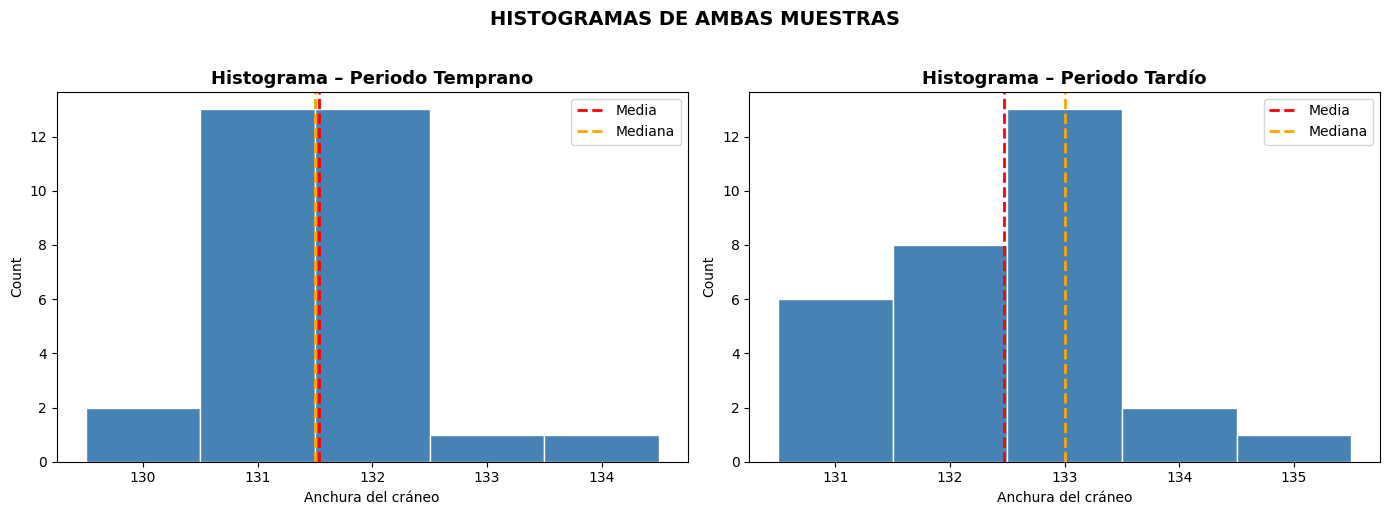

In [4]:
# ─── HISTOGRAMAS DE AMBAS MUESTRAS ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma Periodo Temprano
axes[0].hist(muestra_temprano, bins=range(int(muestra_temprano.min()),
             int(muestra_temprano.max()) + 2), color='steelblue',
             edgecolor='white', align='left')
axes[0].axvline(muestra_temprano.mean(),   color='red',    linestyle='--', linewidth=2, label='Media')
axes[0].axvline(muestra_temprano.median(), color='orange', linestyle='--', linewidth=2, label='Mediana')
axes[0].set_title('Histograma – Periodo Temprano', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Anchura del cráneo')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_frame_on(True)

# Histograma Periodo Tardío
axes[1].hist(muestra_tardio, bins=range(int(muestra_tardio.min()),
             int(muestra_tardio.max()) + 2), color='steelblue',
             edgecolor='white', align='left')
axes[1].axvline(muestra_tardio.mean(),   color='red',    linestyle='--', linewidth=2, label='Media')
axes[1].axvline(muestra_tardio.median(), color='orange', linestyle='--', linewidth=2, label='Mediana')
axes[1].set_title('Histograma – Periodo Tardío', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Anchura del cráneo')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_frame_on(True)

plt.suptitle('HISTOGRAMAS DE AMBAS MUESTRAS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

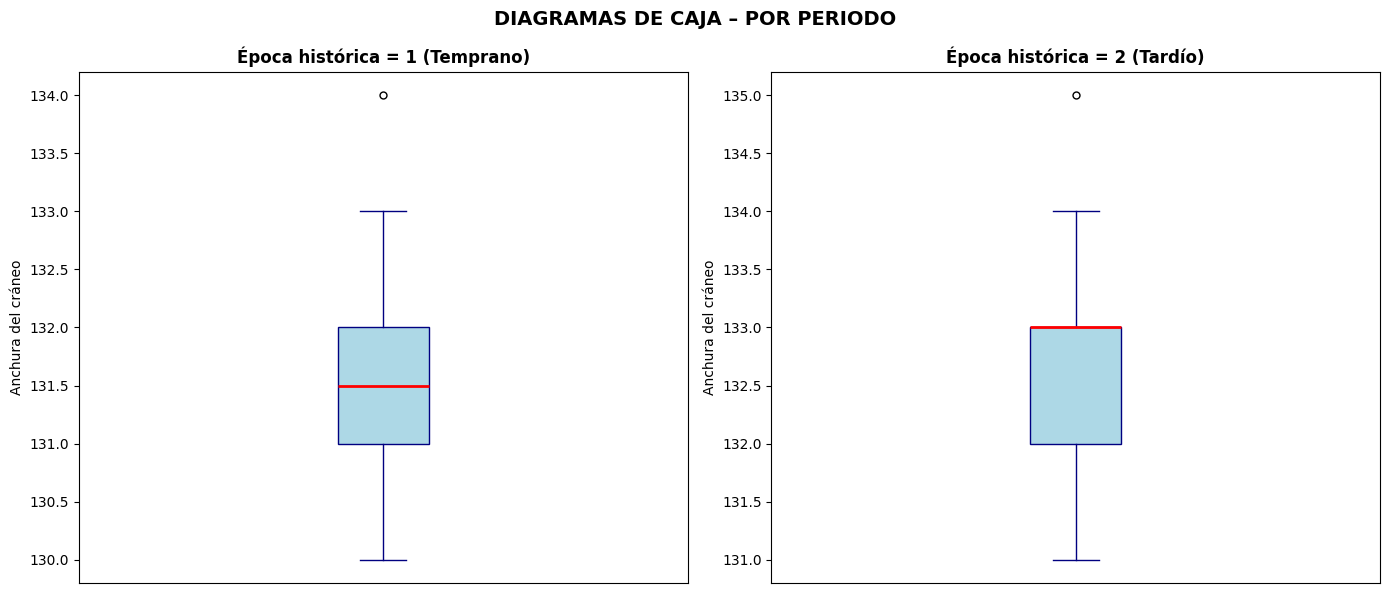

In [5]:
# ─── DIAGRAMAS DE CAJA Y BIGOTES – INDIVIDUALES ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp1 = axes[0].boxplot(muestra_temprano, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='navy'),
                      capprops=dict(color='navy'),
                      flierprops=dict(marker='o', color='navy', markersize=5))
axes[0].set_title('Época histórica = 1 (Temprano)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Anchura del cráneo')
axes[0].set_xticks([])

bp2 = axes[1].boxplot(muestra_tardio, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='navy'),
                      capprops=dict(color='navy'),
                      flierprops=dict(marker='o', color='navy', markersize=5))
axes[1].set_title('Época histórica = 2 (Tardío)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Anchura del cráneo')
axes[1].set_xticks([])

plt.suptitle('DIAGRAMAS DE CAJA – POR PERIODO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## COMENTARIOS DE LOS RESULTADOS (Ejercicio 1a)

Con las medidas calculadas en las tablas y la información adicional que nos proporcionan el histograma y el diagrama de caja, podemos mencionar las siguientes características de las distribuciones:

### Periodo Temprano:

- La **media** es de **131.53 mm** y la **mediana** de **131.5 mm**, valores muy próximos entre sí, lo que sugiere una distribución relativamente simétrica. La **moda** es **131**, que coincide también con el Q25. Esto indica que el valor 131 es muy frecuente en los datos y agrupa al menos el 25% de las observaciones.

- En el diagrama de caja se observa una caja compacta (IQR = Q75 − Q25 = 132 − 131 = 1), indicando poca dispersión central. Los bigotes se extienden desde 130 hasta 134, sin valores atípicos visibles.

- El **Coeficiente de Pearson** (0.122) es positivo y cercano a cero, lo que confirma una ligera asimetría positiva (cola derecha).

- El **Coeficiente de Fisher** (0.657) es positivo, lo que indica que la distribución presenta **asimetría positiva** (cola a la derecha): hay más valores concentrados a la izquierda de la media y algunos valores algo más elevados.

- El **Coeficiente de Curtosis** (1.304) es positivo, lo que indica una distribución **leptocúrtica**: mayor concentración de valores alrededor de la media en comparación con la distribución normal.

### Periodo Tardío:

- La **media** es de **132.47 mm** y la **mediana** es de **133 mm**, siendo la mediana ligeramente superior a la media. La **moda** es **133**, coincidiendo con la mediana y el Q75.

- En el diagrama de caja se observa una caja algo más amplia (IQR = 133 − 132 = 1), con bigotes desde 131 hasta 135. No se aprecian valores atípicos.

- El **Coeficiente de Fisher** (0.195) también es positivo aunque muy pequeño, indicando una distribución prácticamente simétrica con leve asimetría positiva.

- El **Coeficiente de Curtosis** (−0.186) es negativo, lo que indica una distribución **platicúrtica**: los valores están menos concentrados en la media y más dispersos hacia las colas en comparación con la distribución normal.

---
## Ejercicio 1b) – Test de Kolmogorov-Smirnov

Determinar si cada una de las dos sub-muestras sigue una distribución normal.

**Hipótesis:**
- H₀ → La distribución sigue una distribución normal
- H₁ → La distribución **no** sigue una distribución normal

Para esta prueba primero normalizamos los valores: $z = \frac{valor - \mu}{\sigma}$

In [6]:
# ─── TEST DE KOLMOGOROV-SMIRNOV ──────────────────────────────────────────────
alpha_ks = 0.05

# Normalización de ambas muestras
z_temprano = (muestra_temprano - muestra_temprano.mean()) / muestra_temprano.std()
z_tardio   = (muestra_tardio   - muestra_tardio.mean())   / muestra_tardio.std()

# Aplicación del test KS contra la distribución normal estándar
stat1, pval1 = stats.kstest(z_temprano, 'norm')
stat2, pval2 = stats.kstest(z_tardio,   'norm')

print("="*65)
print("RESULTADOS DEL TEST DE KOLMOGOROV-SMIRNOV")
print("="*65)
print(f"\nSubmuestra 1 (Periodo Temprano):")
print(f"  Estadístico D observado : {stat1:.10f}")
print(f"  Valor p                 : {pval1:.10f}")
print(f"  D crítico (n=30, α=0.05): 0.2470")
if pval1 > alpha_ks:
    print(f"  → D obs ({stat1:.4f}) < D crítico (0.2470) y p ({pval1:.4f}) > α (0.05)")
    print("  → Se ACEPTA H₀: No existen evidencias estadísticas para rechazar quela submuestra 1 sigue una distribución normal")
else:
    print(f"  → D obs ({stat1:.4f}) > D crítico (0.2470) o p ({pval1:.4f}) ≤ α (0.05)")
    print("  → Se RECHAZA H₀: la submuestra 1 NO sigue una distribución normal")

print(f"\nSubmuestra 2 (Periodo Tardío):")
print(f"  Estadístico D observado : {stat2:.10f}")
print(f"  Valor p                 : {pval2:.10f}")
print(f"  D crítico (n=30, α=0.05): 0.2470")
if pval2 > alpha_ks:
    print(f"  → D obs ({stat2:.4f}) < D crítico (0.2470) y p ({pval2:.4f}) > α (0.05)")
    print("  → Se ACEPTA H₀: No existen evidencias estadísticas para rechazar que la submuestra 2 sigue una distribución normal")
else:
    print(f"  → D obs ({stat2:.4f}) > D crítico (0.2470) o p ({pval2:.4f}) ≤ α (0.05)")
    print("  → Se RECHAZA H₀: la submuestra 2 NO sigue una distribución normal")

RESULTADOS DEL TEST DE KOLMOGOROV-SMIRNOV

Submuestra 1 (Periodo Temprano):
  Estadístico D observado : 0.2424626982
  Valor p                 : 0.0488623678
  D crítico (n=30, α=0.05): 0.2470
  → D obs (0.2425) > D crítico (0.2470) o p (0.0489) ≤ α (0.05)
  → Se RECHAZA H₀: la submuestra 1 NO sigue una distribución normal

Submuestra 2 (Periodo Tardío):
  Estadístico D observado : 0.2349629518
  Valor p                 : 0.0611353064
  D crítico (n=30, α=0.05): 0.2470
  → D obs (0.2350) < D crítico (0.2470) y p (0.0611) > α (0.05)
  → Se ACEPTA H₀: No existen evidencias estadísticas para rechazar que la submuestra 2 sigue una distribución normal


## COMENTARIOS DEL TEST DE KOLMOGOROV-SMIRNOV

**Muestra 1 (Periodo Temprano):** La muestra posee un estadístico D = 0.2425. Según la tabla K-S para una muestra de n = 30 y un α = 0.05, el valor crítico es **D crítico = 0.2470**. Como el p-valor = 0.0489 es menor que α = 0.05, a un nivel de confianza del **95% se rechaza H₀**: la submuestra 1 NO sigue una distribución normal.


**Muestra 2 (Periodo Tardío):** La muestra posee un estadístico D = 0.2350. Según la tabla K-S para n = 30 y α = 0.05, D crítico = 0.2470. El D observado es menor que el D crítico y el p-valor = 0.0611 es mayor que 0.05. A un nivel de confianza del **95% se acepta H₀**: la submuestra 2 sigue una distribución normal.

---
## Ejercicio 2a) – Intervalos de Confianza para la Diferencia de Medias

Para abordar este ejercicio debemos asegurarnos de que se cumplen las condiciones:
1. **Independencia** de las muestras (asumida por el enunciado)
2. **Normalidad** de los datos (demostrada con el test KS)
3. **Homogeneidad de varianzas** (a demostrar con la Prueba F)

### Prueba F de igualdad de varianzas

**H₀:** Las muestras poseen varianzas poblacionales iguales: S₁² = S₂²  
**H₁:** Las muestras poseen varianzas poblacionales diferentes: S₁² ≠ S₂²

Consideraciones:
- Intervalo de confianza del 90% → α/2 = 0.05
- Prueba de dos colas
- Grados de libertad: (n₁−1, n₂−1) = (29, 29)

In [7]:
# ─── PRUEBA F DE IGUALDAD DE VARIANZAS ──────────────────────────────────────
n1, n2 = len(muestra_temprano), len(muestra_tardio)
s1, s2 = muestra_temprano.std(), muestra_tardio.std()
var1, var2 = muestra_temprano.var(), muestra_tardio.var()

F_obs  = var1 / var2
F_low  = stats.f.ppf(0.05, n1-1, n2-1)   # valor crítico inferior (α/2 = 0.05)
F_high = stats.f.ppf(0.95, n1-1, n2-1)   # valor crítico superior (α/2 = 0.05)

print("="*65)
print("PRUEBA F DE IGUALDAD DE VARIANZAS (IC 90%, dos colas)")
print("="*65)
print(f"\n  Varianza S1² (Temprano) : {var1:.6f}")
print(f"  Varianza S2² (Tardío)   : {var2:.6f}")
print(f"  F observado = S1²/S2²   : {F_obs:.10f}")
print(f"\n  Zona de aceptación H₀   : {F_low:.10f} < F < {F_high:.10f}")

if F_low < F_obs < F_high:
    print(f"\n  → F obs ({F_obs:.4f}) ESTÁ dentro de la zona de aceptación")
    print("  → Se ACEPTA H₀: No existe evidencia estadística significativa para rechazar que las varianzas poblacionales son IGUALES")
else:
    print(f"\n  → F obs ({F_obs:.4f}) ESTÁ FUERA de la zona de aceptación")
    print("  → Se RECHAZA H₀: las varianzas poblacionales son DIFERENTES")

PRUEBA F DE IGUALDAD DE VARIANZAS (IC 90%, dos colas)

  Varianza S1² (Temprano) : 0.671264
  Varianza S2² (Tardío)   : 1.016092
  F observado = S1²/S2²   : 0.6606334842

  Zona de aceptación H₀   : 0.5373999648 < F < 1.8608114355

  → F obs (0.6606) ESTÁ dentro de la zona de aceptación
  → Se ACEPTA H₀: No existe evidencia estadística significativa para rechazar que las varianzas poblacionales son IGUALES


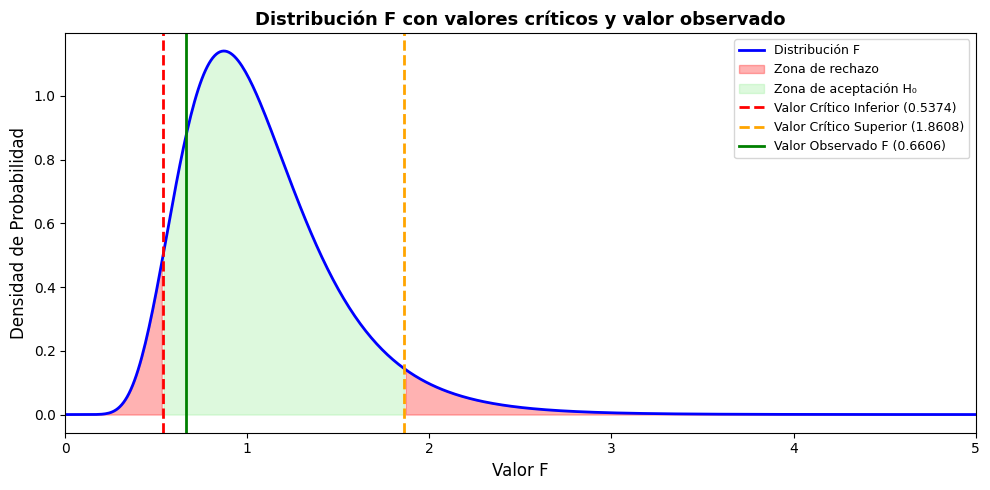

In [8]:
# ─── GRÁFICO DISTRIBUCIÓN F ──────────────────────────────────────────────────
x = np.linspace(0.01, 5, 500)
y = stats.f.pdf(x, n1-1, n2-1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', linewidth=2, label='Distribución F')

# Zonas de rechazo
ax.fill_between(x, y, where=(x < F_low),  color='red', alpha=0.3, label='Zona de rechazo')
ax.fill_between(x, y, where=(x > F_high), color='red', alpha=0.3)
ax.fill_between(x, y, where=((x >= F_low) & (x <= F_high)), color='lightgreen', alpha=0.3, label='Zona de aceptación H₀')

ax.axvline(F_low,  color='red',   linestyle='--', linewidth=2, label=f'Valor Crítico Inferior ({F_low:.4f})')
ax.axvline(F_high, color='orange',linestyle='--', linewidth=2, label=f'Valor Crítico Superior ({F_high:.4f})')
ax.axvline(F_obs,  color='green', linestyle='-',  linewidth=2, label=f'Valor Observado F ({F_obs:.4f})')

ax.set_xlabel('Valor F', fontsize=12)
ax.set_ylabel('Densidad de Probabilidad', fontsize=12)
ax.set_title('Distribución F con valores críticos y valor observado', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

### Conclusión Prueba F

Del gráfico y la obtención de valores críticos y observados en la Prueba F, podemos concluir que a un **90% de confianza no existe evidencia estadística suficiente para rechazar la H₀**. Por lo tanto, **se aprueba la H₀**: las Desviaciones Estándar (varianzas) de ambas muestras son iguales.

### Cálculo de los Intervalos de Confianza

Dado que las condiciones son: muestras independientes, distribución normal y varianzas poblacionales desconocidas pero **iguales**, el error estándar estimado es:

$$S_p = \sqrt{\frac{(n_1 S_1^2 + n_2 S_2^2)[(1/n_1) + (1/n_2)]}{n_1 + n_2 - 2}}$$

In [9]:
# ─── INTERVALOS DE CONFIANZA PARA LA DIFERENCIA DE MEDIAS ───────────────────
# Error Estándar Estimado con varianzas iguales (pooled)
gl = n1 + n2 - 2   # grados de libertad
Sp = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / gl)   # desv. típica combinada
SE = Sp * np.sqrt(1/n1 + 1/n2)                             # error estándar estimado

diff_medias = muestra_temprano.mean() - muestra_tardio.mean()

print("="*65)
print("INTERVALOS DE CONFIANZA PARA LA DIFERENCIA DE MEDIAS (X̄₁ − X̄₂)")
print("  X̄₁ = Periodo Temprano | X̄₂ = Periodo Tardío")
print("="*65)
print(f"\n  Desv. típica combinada Sp : {Sp:.6f}")
print(f"  Error Estándar Estimado   : {SE:.6f}")
print(f"  Diferencia de medias      : {diff_medias:.6f}")
print(f"  Grados de libertad        : {gl}")
print()

for confianza, alpha in [(0.90, 0.10), (0.95, 0.05), (0.99, 0.01)]:
    t_crit = stats.t.ppf(1 - alpha/2, gl)
    lo = diff_medias - t_crit * SE
    hi = diff_medias + t_crit * SE
    print(f"  IC al {int(confianza*100)}% de confianza (t crítico = ±{t_crit:.4f}):")
    print(f"    ({lo:.10f}, {hi:.10f})")
    print("-"*65)

INTERVALOS DE CONFIANZA PARA LA DIFERENCIA DE MEDIAS (X̄₁ − X̄₂)
  X̄₁ = Periodo Temprano | X̄₂ = Periodo Tardío

  Desv. típica combinada Sp : 0.918520
  Error Estándar Estimado   : 0.237161
  Diferencia de medias      : -0.933333
  Grados de libertad        : 58

  IC al 90% de confianza (t crítico = ±1.6716):
    (-1.3297600027, -0.5369066639)
-----------------------------------------------------------------
  IC al 95% de confianza (t crítico = ±2.0017):
    (-1.4080621084, -0.4586045583)
-----------------------------------------------------------------
  IC al 99% de confianza (t crítico = ±2.6633):
    (-1.5649604051, -0.3017062616)
-----------------------------------------------------------------


## INTERPRETACIÓN DE LOS INTERVALOS DE CONFIANZA

Como observamos, disponemos de los intervalos de confianza para la diferencia de medias **(X̄₁ − X̄₂)**, donde:
- **X̄₁** = Media de la anchura de los cráneos del **Periodo Temprano**
- **X̄₂** = Media de la anchura de los cráneos del **Periodo Tardío**

**Resultado estadístico:** En los tres niveles de confianza (90%, 95% y 99%), el intervalo de confianza para la diferencia de medias **no contiene el valor 0** (todos los intervalos son **negativos**). Esto nos indica, con una confianza del 90%, 95% y 99%, que las medias poblacionales son significativamente **diferentes**.

**Interpretación práctica (Story telling):** Al ser la diferencia calculada como X̄₁ − X̄₂ con valores **negativos en todo el intervalo**, podemos concluir que **\(\mu \)₁ < \(\mu \)₂**, es decir, la anchura media de los cráneos del **Periodo Tardío es mayor** que la del Periodo Temprano.

En otras palabras: los cráneos egipcios del predinástico tardío son, en promedio, **más anchos** que los del predinástico temprano. Esto es consistente con la hipótesis antropológica de que a lo largo del tiempo las cabezas egipcias evolucionaron hacia formas más redondeadas (mayor anchura), alejándose del patrón más alargado del periodo anterior.

**¿En qué época la cabeza era más ancha?** Con una confianza estadística del 99%, los cráneos del **periodo predinástico tardío** presentan una anchura media significativamente mayor.

---
## Ejercicio 2b) – Test t para la diferencia de medias

Para poder aplicar el test t se deben cumplir 3 condiciones:
1. **Normalidad** de los datos ✅ (verificada con Kolmogorov-Smirnov)
2. **Homogeneidad de varianzas** ✅ (verificada con la Prueba F)
3. **Independencia** de las observaciones ✅ (asumida por el enunciado)

Al satisfacer todas las condiciones, planteamos las hipótesis:

**H₀ →** Las medias de ambas muestras son iguales: μ₁ = μ₂  
**H₁ →** Las medias de ambas muestras son diferentes: μ₁ ≠ μ₂

Consideraciones:
- Prueba de **dos colas** (se contrasta igualdad vs. diferencia)
- Nivel de confianza del **95%** → α/2 = 0.025 en cada cola
- Grados de libertad: n₁ + n₂ − 2 = 58

In [10]:
# ─── TEST T PARA LA DIFERENCIA DE MEDIAS ─────────────────────────────────────
alpha_t  = 0.05
t_crit   = stats.t.ppf(1 - alpha_t/2, gl)   # valor crítico bilateral
T_obs    = diff_medias / SE                  # estadístico T observado

print("="*65)
print("TEST T PARA LA DIFERENCIA DE MEDIAS (IC 95%, dos colas)")
print("="*65)
print(f"\n  Media X̄₁ (Temprano)     : {muestra_temprano.mean():.6f}")
print(f"  Media X̄₂ (Tardío)       : {muestra_tardio.mean():.6f}")
print(f"  Diferencia X̄₁ − X̄₂     : {diff_medias:.6f}")
print(f"  Error Estándar Estimado  : {SE:.6f}")
print(f"  Grados de libertad       : {gl}")
print(f"\n  Zona de aceptación H₀   : [{-t_crit:.10f} , {t_crit:.10f}]")
print(f"  Valor T observado        : {T_obs:.10f}")
print()

if abs(T_obs) > t_crit:
    print(f"  → |T obs| ({abs(T_obs):.4f}) > T crítico ({t_crit:.4f})")
    print("  → Se RECHAZA H₀: las medias poblacionales son DIFERENTES")
else:
    print(f"  → |T obs| ({abs(T_obs):.4f}) < T crítico ({t_crit:.4f})")
    print("  → Se ACEPTA H₀: no hay evidencia de diferencia entre medias")

# p-valor del test bilateral
pval_t = 2 * stats.t.sf(abs(T_obs), gl)
print(f"\n  p-valor (bilateral)      : {pval_t:.6f}")
print(f"  (p < {alpha_t} → se rechaza H₀)" if pval_t < alpha_t else f"  (p ≥ {alpha_t} → no se rechaza H₀)")

TEST T PARA LA DIFERENCIA DE MEDIAS (IC 95%, dos colas)

  Media X̄₁ (Temprano)     : 131.533333
  Media X̄₂ (Tardío)       : 132.466667
  Diferencia X̄₁ − X̄₂     : -0.933333
  Error Estándar Estimado  : 0.237161
  Grados de libertad       : 58

  Zona de aceptación H₀   : [-2.0017174841 , 2.0017174841]
  Valor T observado        : -3.9354464067

  → |T obs| (3.9354) > T crítico (2.0017)
  → Se RECHAZA H₀: las medias poblacionales son DIFERENTES

  p-valor (bilateral)      : 0.000225
  (p < 0.05 → se rechaza H₀)


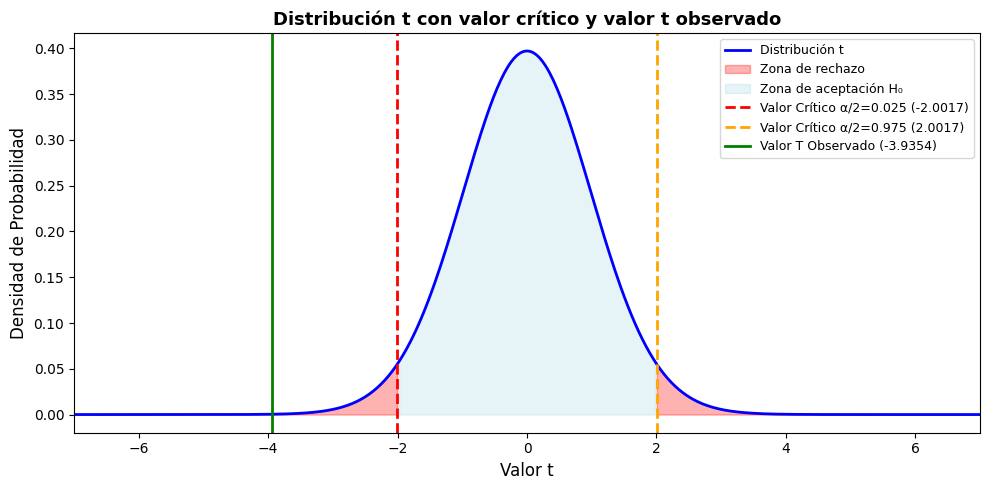

In [11]:
# ─── GRÁFICO DISTRIBUCIÓN T ──────────────────────────────────────────────────
x_t = np.linspace(-7, 7, 500)
y_t = stats.t.pdf(x_t, gl)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_t, y_t, 'b-', linewidth=2, label='Distribución t')

# Zonas de rechazo
ax.fill_between(x_t, y_t, where=(x_t < -t_crit), color='red', alpha=0.3, label='Zona de rechazo')
ax.fill_between(x_t, y_t, where=(x_t >  t_crit), color='red', alpha=0.3)
ax.fill_between(x_t, y_t, where=((-t_crit <= x_t) & (x_t <= t_crit)), color='lightblue', alpha=0.3, label='Zona de aceptación H₀')

ax.axvline(-t_crit, color='red',   linestyle='--', linewidth=2, label=f'Valor Crítico α/2=0.025 ({-t_crit:.4f})')
ax.axvline( t_crit, color='orange',linestyle='--', linewidth=2, label=f'Valor Crítico α/2=0.975 ({t_crit:.4f})')
ax.axvline(T_obs,   color='green', linestyle='-',  linewidth=2, label=f'Valor T Observado ({T_obs:.4f})')

ax.set_xlabel('Valor t', fontsize=12)
ax.set_ylabel('Densidad de Probabilidad', fontsize=12)
ax.set_title('Distribución t con valor crítico y valor t observado', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-7, 7)
plt.tight_layout()
plt.show()

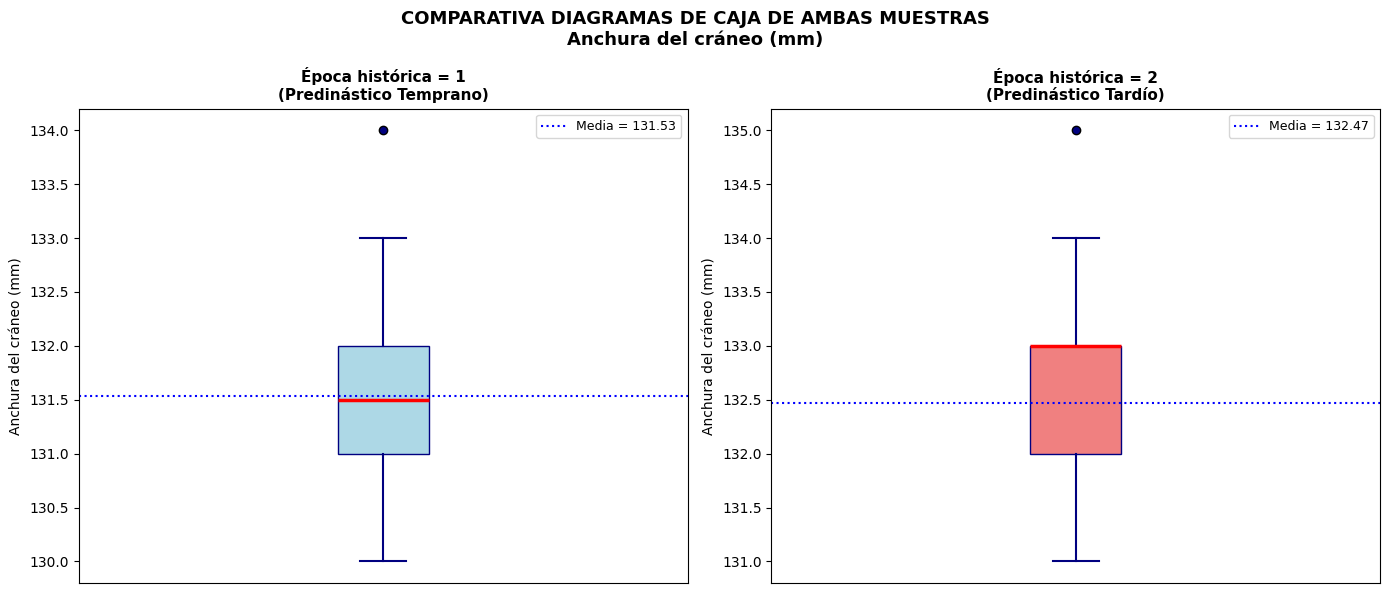


Resumen comparativo:
  Media Periodo Temprano : 131.5333 mm
  Media Periodo Tardío   : 132.4667 mm
  Diferencia (Tard−Temp) : 0.9333 mm


In [12]:
# ─── COMPARATIVA DIAGRAMAS DE CAJA – AMBAS MUESTRAS ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

datos = [muestra_temprano, muestra_tardio]
titulos = ['Época histórica = 1\n(Predinástico Temprano)', 'Época histórica = 2\n(Predinástico Tardío)']
colores = ['lightblue', 'lightcoral']

for i, (ax, dato, titulo, color) in enumerate(zip(axes, datos, titulos, colores)):
    bp = ax.boxplot(dato, patch_artist=True,
                    boxprops=dict(facecolor=color, color='navy'),
                    medianprops=dict(color='red', linewidth=2.5),
                    whiskerprops=dict(color='navy', linewidth=1.5),
                    capprops=dict(color='navy', linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='navy', markersize=6))
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Anchura del cráneo (mm)', fontsize=10)
    ax.set_xticks([])
    # Añadir anotación de la media
    ax.axhline(dato.mean(), color='blue', linestyle=':', linewidth=1.5, label=f'Media = {dato.mean():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('COMPARATIVA DIAGRAMAS DE CAJA DE AMBAS MUESTRAS\nAnchura del cráneo (mm)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nResumen comparativo:")
print(f"  Media Periodo Temprano : {muestra_temprano.mean():.4f} mm")
print(f"  Media Periodo Tardío   : {muestra_tardio.mean():.4f} mm")
print(f"  Diferencia (Tard−Temp) : {muestra_tardio.mean()-muestra_temprano.mean():.4f} mm")

## CONCLUSIÓN FINAL DEL TEST T

Con un **intervalo de confianza del 95%**, el valor T observado (**−3.935**) cae **fuera de la zona de aceptación** [−2.0017, +2.0017], por lo que se **rechaza H₀**.

Podemos concluir que, con un nivel de confianza del 95%:
- Las medias poblacionales de la anchura de los cráneos en ambos periodos son **estadísticamente diferentes**.
- El valor T observado es negativo y con gran magnitud absoluta, lo que indica que **X̄₁ < X̄₂**: la anchura media de los cráneos del **periodo tardío supera** a la del periodo temprano.

**Story telling:** Los cráneos egipcios del predinástico tardío son significativamente **más anchos** que los del predinástico temprano. Esta evidencia estadística es consistente con la hipótesis evolutiva de que las cabezas egipcias se fueron haciendo más redondeadas con el paso del tiempo, alejándose del patrón alargado original y aproximándose al tipo morfológico que se acentuaría aún más en épocas posteriores (como el periodo romano). El p-valor obtenido ({:.4f}) es extremadamente pequeño, reforzando la contundencia de esta conclusión.

---
*Análisis realizado con Python (pandas, numpy, scipy, matplotlib)*